# Data preprocessing

For all datasets, I set 'sex' and 'smokes' variables as categorical.

I will now enumerate and shortly describe all resolved incosistencies related to each dataset.

### NL dataset

No inconsistencies were detected, which is in line with the provided instructions.

### UK dataset

#### Inconsistencies:

- inconsistent 'smokes' values

Instead of 'yes'/'no', there was 1/0. I assumed 0 to be 'no' and 1 to be 'yes' and changed the values accordingly.


- inconsistent 'sex' values

Some case size and wording inconsistencies, i.e. 'woman' instead of 'female', or 'mALE' instead of 'male'.

- 'height' and 'weight' in british measurement units

Transformation was necessary.

- negative height

One value of height was negative. For learning purposes, I assumed this value to be missing and set it to a variable median.

- weights outside of range of possible values

Some weights were set to 999, which is commonly used notation for missing data. I imputed variable median in their place.



### PL dataset

#### Inconsistencies:

- missing data

For the learning purposes, and according to instruction, I ignored (i.e. complete case analysis) the missing data.

- inconsistent 'smokes' values

Instead of 'yes'/'no', there was True/False. I assumed False to be 'no' and True to be 'yes' and changed the values accordingly.

- 'heigth' written with an error

I renamed 'heigth' to 'height'

-  duplicated id

Some 'id' values were duplicated. Since I assume the desing of the study is not repeated measurements, and given not only 'id' values, but entire rows were identical, I deleted the duplicated rows, assuming them to be a mistake.


### US dataset

#### Inconsistencies:

- 'height' variable is largely missing

Almost 50% of the 'height' values were misssing. In real case scenario, I would try to identify the kind of missingness and impute the NAs accordingly. As such action was deemed beyond the scope of this excercise, I substitued the missing values with the variable median.


### Additonal note

While merging the datasets, I noticed that some 'id' values are present in one dataset, but not the other. I inspected the 'id' values and verified that each dataset contains only 'id' values with a correct identifying letter (i.e. NL, UK, S0, S1). Additonaly, I found it is a common case with genomic data. As such, I assumed this is not an inconsistency to be solved, but quality of the recorded data, hence I took no further actions to resolve the discrepancy.


# Data analysis

First, BMI score is needed for the desired visualisations.

In [ ]:
import pandas as pd

df = pd.read_csv('out/combined_dataset.csv')

df['bmi'] = df['weight'] / (df['height'] / 100) ** 2 #bmi calculation
df['bmi'].describe() #all bmi values are in the normal range

count    3260.000000
mean       26.202880
std         4.497231
min        11.170149
25%        23.120624
50%        26.310769
75%        29.090500
max        41.099773
Name: bmi, dtype: float64

Then, distribution of BMI by country is presented.

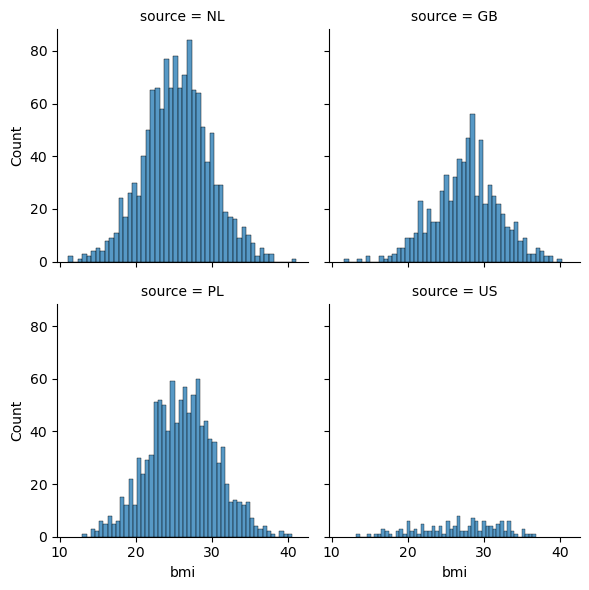

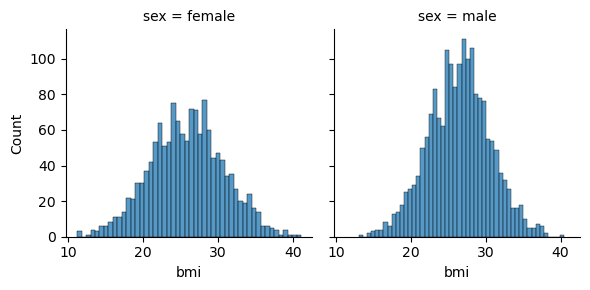

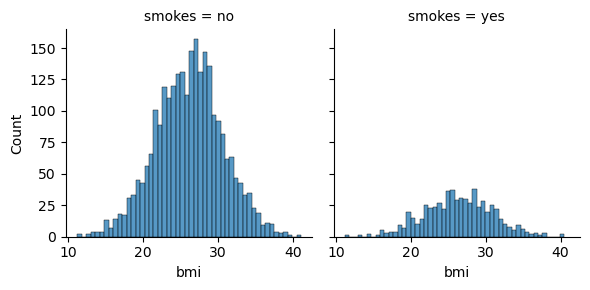

In [31]:
import seaborn as sns

g = sns.FacetGrid(df, col="source", col_wrap=2)
g.map(sns.histplot, "bmi", bins = 50)

g = sns.FacetGrid(df, col="sex", col_wrap=2)
g.map(sns.histplot, "bmi", bins = 50)

g = sns.FacetGrid(df, col="smokes", col_wrap=2)
g.map(sns.histplot, "bmi", bins = 50)



There is clearly less complete observation for US lab observations and smokers, but besides this, BMIs seem to be normally distributed around the mean of 25 in each instance, which is a higher end of healthy BMI.

I now proceed to examining the relations between the BMI and differend values of gene expressions.

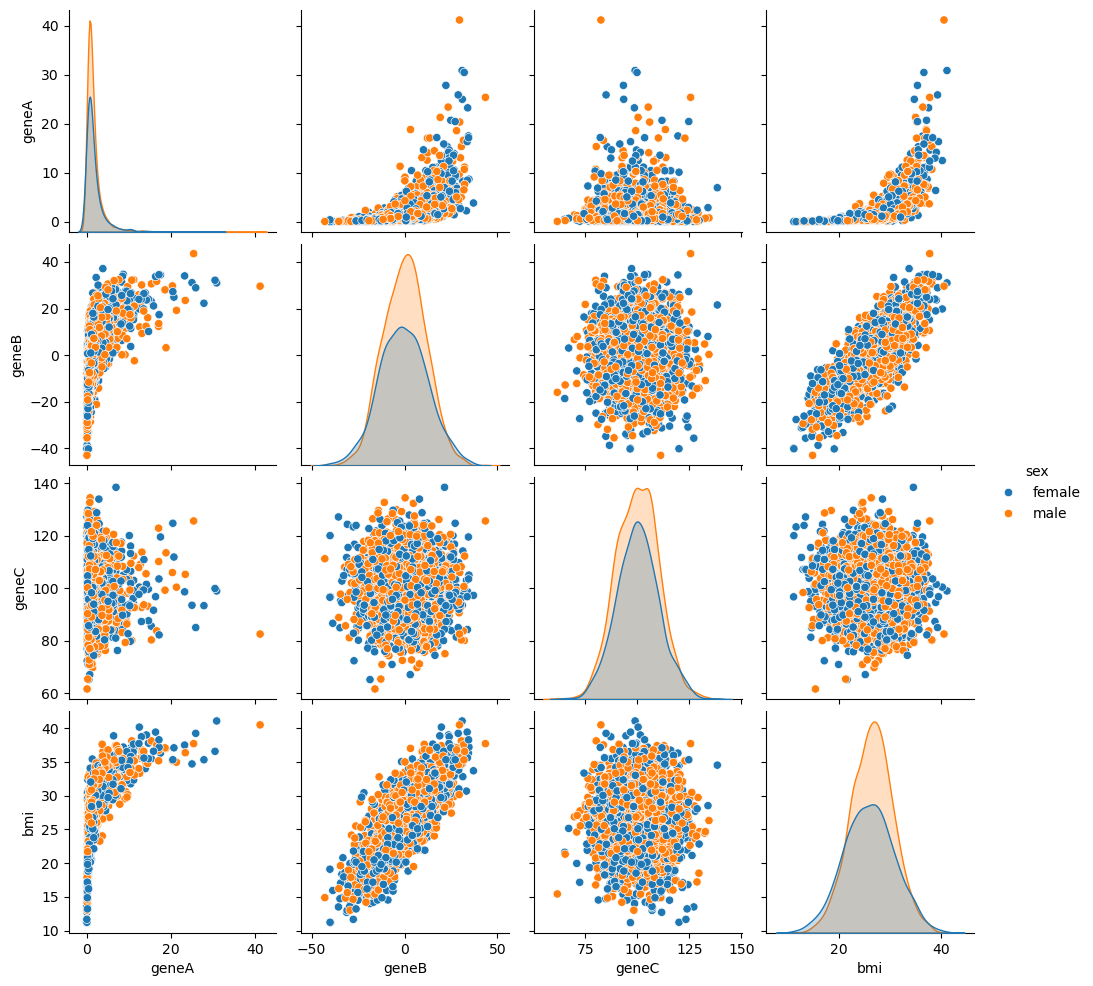

In [29]:
cors = sns.pairplot(df, vars = ['geneA', 'geneB', 'geneC', 'bmi'], hue = 'sex')

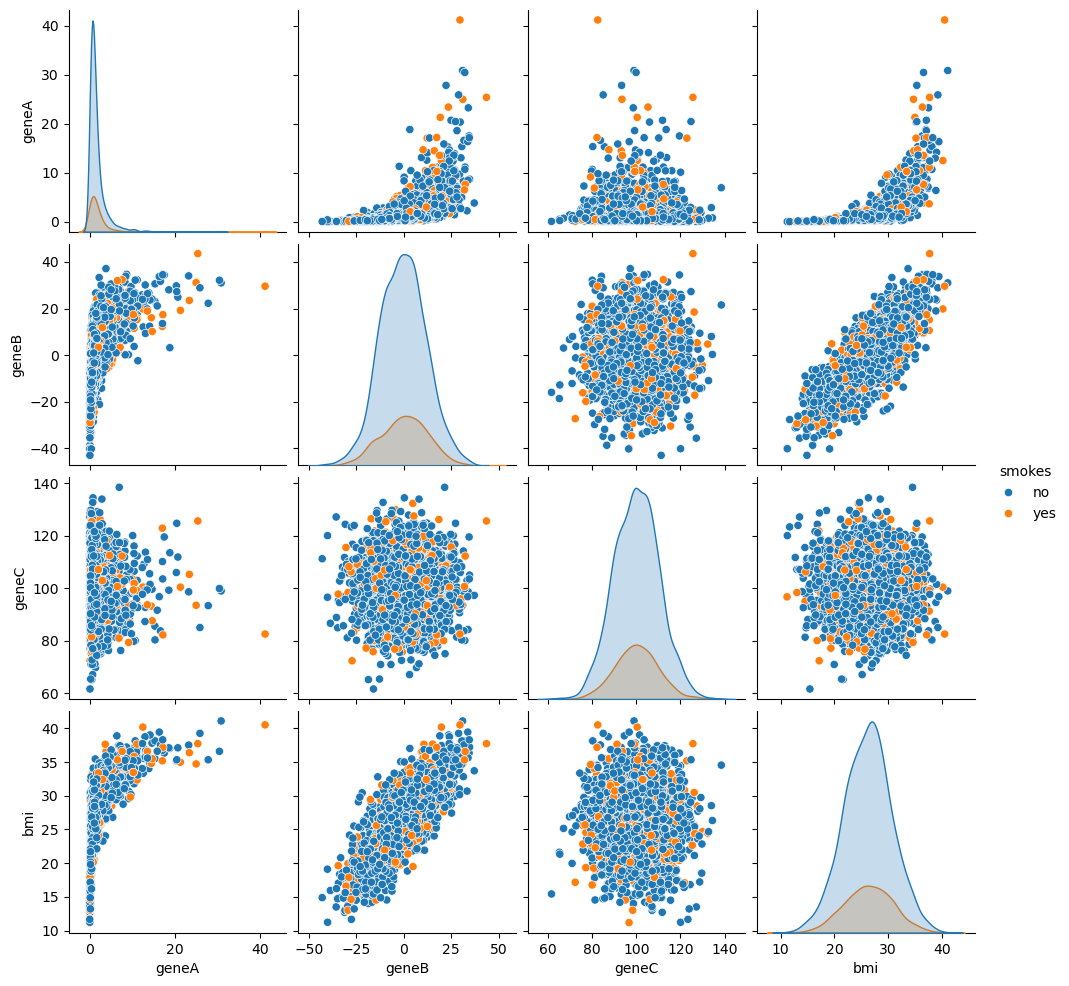

In [30]:
cors = sns.pairplot(df, vars = ['geneA', 'geneB', 'geneC', 'bmi'], hue = 'smokes')

Gene C does not appear to be correlated with BMI, indicating little to no association between the two variables. 

Gene B shows an approximately linear positive relationship with BMI, such that higher Gene B expression levels are associated with higher BMI values. 

In contrast, Gene A exhibits a non-linear relationship with BMI, in which BMI increases in a logarithmic fashion along growing BMI values.

The patterns seem to be independent of sex and smoking status.